# Analysis of Nosofsky & Gold (2018)

Models: 
1. SCM & SCM-mix (from the paper)
2. TCC, TCC-mix (new)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from models import SCM, SCM_mix, TCC, TCC_mix
from models import unpack_SCM_params, unpack_SCM_mix_params, unpack_TCC_params, unpack_TCC_mix_params
from utils import (
    item_colors,
    load_data, attach_mds_distances, extract_observed, prepare_data,
    validity_checks, fit_model,
    compute_aic_bic, print_model_comparison, compute_correlations,
    plot_predicted_vs_observed, plot_predicted_vs_observed_comparison,
    plot_pred_vs_obs_subject_avgpos, plot_aic_bic,
)

# Config

In [2]:
POSITIONS  = [3, 7, 11, 15]
SET_SIZES  = [2, 5, 8]
SUBJECTS   = range(1, 9)
N_ITEMS    = 16
N_SS       = len(SET_SIZES)
N_POS      = len(POSITIONS)

N_POINTS = 500
X_RANGE  = (-3, 10)

FIT_SUBJECTS            = [4]   # set to None to fit all subjects
USE_SINGLE_MDS_SOLUTION = True

# Read Data

In [3]:
data = load_data('Data', SET_SIZES, POSITIONS)
data = attach_mds_distances(data, list(SUBJECTS), SET_SIZES, POSITIONS,
                            use_single=USE_SINGLE_MDS_SOLUTION)

if FIT_SUBJECTS is not None:
    SUBJECTS = FIT_SUBJECTS

data_matrix   = extract_observed(data, SUBJECTS, SET_SIZES, POSITIONS)
prepared_data = prepare_data(data, SUBJECTS, SET_SIZES, POSITIONS)
total_counts  = data_matrix.sum()

# Optimization

In [4]:
def neg_log_likelihood(params, model, observed_counts, prep_data,
                       n_points=N_POINTS, x_range=X_RANGE):
    if not validity_checks(params, model):
        return 1e10

    if model is SCM or model is SCM_mix:
        predicted_probs = model(params_vec=params, prepared_data=prep_data)[0]
    elif model is TCC or model is TCC_mix:
        predicted_probs = model(params_vec=params, prepared_data=prep_data,
                                n_points=n_points, x_range=x_range)[0]

    eps = 1e-12
    return -np.sum(observed_counts * np.log(predicted_probs + eps)) / total_counts

## SCM

In [5]:
initial_params_SCM = np.concatenate([
    np.repeat(1/16, 15),   # biases
    [1.0],                 # B
    np.repeat(0.01, 3),    # c per set size
])
bounds_SCM = (
    [(0, 1)]    * 15 +
    [(0, None)]      +
    [(0, None)] * 3
)

SCM_fit = fit_model(loss_func=neg_log_likelihood,
                    initial_params=initial_params_SCM,
                    params_bounds=bounds_SCM,
                    model=SCM,
                    observed_counts=data_matrix,
                    prep_data=prepared_data)

=== Warmup ===
  [warmup] Iteration   10: loss = 2.248934
  [warmup] Iteration   20: loss = 1.480478
  [warmup] Iteration   30: loss = 1.466366
  [warmup] Iteration   40: loss = 1.387611
  [warmup] Iteration   50: loss = 1.382254
  [warmup] Iteration   60: loss = 1.367486
  [warmup] Iteration   70: loss = 1.366782
  [warmup] Iteration   80: loss = 1.362982
  [warmup] Iteration   90: loss = 1.359705
  [warmup] Iteration  100: loss = 1.356106
  [warmup] Iteration  110: loss = 1.351791
  [warmup] Iteration  120: loss = 1.346989
  [warmup] Iteration  130: loss = 1.338664
  [warmup] Iteration  140: loss = 1.338376
  [warmup] Iteration  150: loss = 1.337365
  [warmup] Iteration  160: loss = 1.335520
  [warmup] Iteration  170: loss = 1.334439
  [warmup] Iteration  180: loss = 1.333867
  [warmup] Iteration  190: loss = 1.333695
  [warmup] Iteration  200: loss = 1.333655
Warmup done: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.333654

=== Final fit ===
Final done:  CONVERGENCE: N

In [6]:
biases, B, c = unpack_SCM_params(SCM_fit.x)
print(f'Total {len(SCM_fit.x)} free parameters')
print(f'Negative log-likelihood: {SCM_fit.fun:.3f}\n')
print(f'Biases:\n{biases.round(3)}\n')
print(f'Boost B: {B:.3f}\n')
print(f'c per set size: {c.round(3)}')

Total 19 free parameters
Negative log-likelihood: 1.334

Biases:
[0.035 0.026 0.063 0.051 0.028 0.09  0.082 0.045 0.023 0.057 0.102 0.098
 0.095 0.067 0.079 0.059]

Boost B: 14.380

c per set size: [6.734 2.373 1.476]


## SCM-mix

In [7]:
initial_params_SCM_mix = np.concatenate([
    SCM_fit.x[:15],        # biases from SCM
    [1.0],                 # B
    SCM_fit.x[-3:],        # c from SCM
    [0.9, 0.8, 0.7],       # p_mem
    [1.0],                 # gamma
])
bounds_SCM_mix = (
    [(0, 1)]    * 15 +
    [(0, None)]      +
    [(0, None)] * 3  +
    [(0, 1)]    * 3  +
    [(0, None)]
)

SCM_mix_fit = fit_model(loss_func=neg_log_likelihood,
                        initial_params=initial_params_SCM_mix,
                        params_bounds=bounds_SCM_mix,
                        model=SCM_mix,
                        observed_counts=data_matrix,
                        prep_data=prepared_data)

=== Warmup ===
  [warmup] Iteration   10: loss = 1.522552
  [warmup] Iteration   20: loss = 1.318306
  [warmup] Iteration   30: loss = 1.235958
  [warmup] Iteration   40: loss = 1.230902
  [warmup] Iteration   50: loss = 1.227747
  [warmup] Iteration   60: loss = 1.210118
  [warmup] Iteration   70: loss = 1.208771
  [warmup] Iteration   80: loss = 1.208662
  [warmup] Iteration   90: loss = 1.207571
  [warmup] Iteration  100: loss = 1.207305
  [warmup] Iteration  110: loss = 1.207272
  [warmup] Iteration  120: loss = 1.207204
  [warmup] Iteration  130: loss = 1.207179
  [warmup] Iteration  140: loss = 1.207090
  [warmup] Iteration  150: loss = 1.206842
  [warmup] Iteration  160: loss = 1.206713
Warmup done: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.206711

=== Final fit ===
Final done:  CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.206711


In [8]:
biases, B, c, p_mem, gamma = unpack_SCM_mix_params(SCM_mix_fit.x)
print(f'Total {len(SCM_mix_fit.x)} free parameters')
print(f'Negative log-likelihood: {SCM_mix_fit.fun:.3f}\n')
print(f'Biases:\n{biases.round(3)}\n')
print(f'Boost B: {B:.3f}\n')
print(f'c per set size: {c.round(3)}\n')
print(f'p_mem per set size: {p_mem.round(3)}\n')
print(f'Gamma: {gamma:.3f}')

Total 23 free parameters
Negative log-likelihood: 1.207

Biases:
[0.031 0.025 0.078 0.055 0.031 0.096 0.098 0.044 0.018 0.047 0.101 0.089
 0.084 0.061 0.088 0.055]

Boost B: 3.693

c per set size: [6.89  4.314 3.904]

p_mem per set size: [0.985 0.688 0.449]

Gamma: 2.555


## TCC

In [9]:
initial_params_TCC = np.concatenate([
    [3.0],                 # d_prime_base
    [0.7, 0.5],            # d_scales for ss=5, ss=8
    [0.01],                # c
    np.repeat(0.0, 16),    # biases
    [0.5],                 # hp_boost
])
bounds_TCC = (
    [(0, None)]       +
    [(0, 1)]     * 2  +
    [(0, None)]       +
    [(None, None)] * 16 +
    [(0, None)]
)

TCC_fit = fit_model(loss_func=neg_log_likelihood,
                    initial_params=initial_params_TCC,
                    params_bounds=bounds_TCC,
                    model=TCC,
                    observed_counts=data_matrix,
                    prep_data=prepared_data,
                    n_points=N_POINTS, x_range=X_RANGE)

=== Warmup ===
  [warmup] Iteration   10: loss = 1.246821
Warmup done: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.237486

=== Final fit ===
Final done:  CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.237486


In [10]:
d_prime_base, d_scales, c, biases, hp_boost = unpack_TCC_params(TCC_fit.x)
print(f'Total {len(TCC_fit.x)} free parameters')
print(f'Negative log-likelihood: {TCC_fit.fun:.3f}\n')
print(f"Base d': {d_prime_base:.3f}\n")
print("d' scales per set size:")
for ss, scale in zip(SET_SIZES, d_scales):
    print(f"  SS={ss}: scale={scale:.3f}  (d'={d_prime_base*scale:.3f})")
print(f'\nc: {c:.3f}\n')
print(f'Biases:\n{biases.round(3)}\n')
print(f'HP boost: {hp_boost:.3f}')

Total 21 free parameters
Negative log-likelihood: 1.237

Base d': 5.186

d' scales per set size:
  SS=2: scale=1.000  (d'=5.186)
  SS=5: scale=0.531  (d'=2.755)
  SS=8: scale=0.370  (d'=1.921)

c: 1.406

Biases:
[-0.323 -0.497  0.161 -0.068 -0.419  0.342  0.322 -0.133 -0.627 -0.026
  0.422  0.285  0.272  0.009  0.266  0.01 ]

HP boost: 1.638


## TCC-mix

In [11]:
initial_params_TCC_mix = np.concatenate([
    [TCC_fit.x[0]],        # d_prime_base
    TCC_fit.x[1:3],        # d_scales
    [TCC_fit.x[3]],        # c
    TCC_fit.x[4:20],       # biases
    [TCC_fit.x[20]],       # hp_boost
    [0.9, 0.8, 0.7],       # p_mem
    [1.0],                 # gamma
])
bounds_TCC_mix = (
    [(0, None)]       +
    [(0, 1)]     * 2  +
    [(0, None)]       +
    [(None, None)] * 16 +
    [(0, None)]       +
    [(0, 1)]     * 3  +
    [(0, None)]
)

TCC_mix_fit = fit_model(loss_func=neg_log_likelihood,
                        initial_params=initial_params_TCC_mix,
                        params_bounds=bounds_TCC_mix,
                        model=TCC_mix,
                        observed_counts=data_matrix,
                        prep_data=prepared_data,
                        n_points=N_POINTS, x_range=X_RANGE)

=== Warmup ===
  [warmup] Iteration   10: loss = 1.235138
  [warmup] Iteration   20: loss = 1.233836
  [warmup] Iteration   30: loss = 1.212507
  [warmup] Iteration   40: loss = 1.209007
  [warmup] Iteration   50: loss = 1.208257
  [warmup] Iteration   60: loss = 1.208152
  [warmup] Iteration   70: loss = 1.208034
Warmup done: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.207966

=== Final fit ===
Final done:  CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.207966


In [12]:
d_prime_base, d_scales, c, biases, hp_boost, p_mem, gamma = unpack_TCC_mix_params(TCC_mix_fit.x)
print(f'Total {len(TCC_mix_fit.x)} free parameters')
print(f'Negative log-likelihood: {TCC_mix_fit.fun:.3f}\n')
print(f"Base d': {d_prime_base:.3f}\n")
print("d' scales per set size:")
for ss, scale in zip(SET_SIZES, d_scales):
    print(f"  SS={ss}: scale={scale:.3f}  (d'={d_prime_base*scale:.3f})")
print(f'\nc: {c:.3f}\n')
print(f'Biases:\n{biases.round(3)}\n')
print(f'HP boost: {hp_boost:.3f}\n')
print(f'p_mem per set size: {p_mem.round(3)}\n')
print(f'Gamma: {gamma:.3f}')

Total 25 free parameters
Negative log-likelihood: 1.208

Base d': 6.711

d' scales per set size:
  SS=2: scale=1.000  (d'=6.711)
  SS=5: scale=0.648  (d'=4.350)
  SS=8: scale=0.561  (d'=3.764)

c: 0.898

Biases:
[-0.419 -0.594  0.137 -0.094 -0.448  0.267  0.286 -0.171 -0.757 -0.131
  0.324  0.216  0.177 -0.056  0.218 -0.069]

HP boost: 0.844

p_mem per set size: [0.986 0.707 0.481]

Gamma: 4.112


# Model Comparison

## AIC & BIC

Model                  n_params      NLL           AIC      AIC_best       BIC      BIC_best
-----------------------------------------------------------------------------------------------
SCM                      19         5121.23      10280.47                10399.28               
SCM-mix                  23         4633.77      9313.54      ***        9457.37      ***       
TCC                      21         4751.95      9545.90                 9677.21                
TCC-mix                  25         4638.59      9327.18                 9483.51                


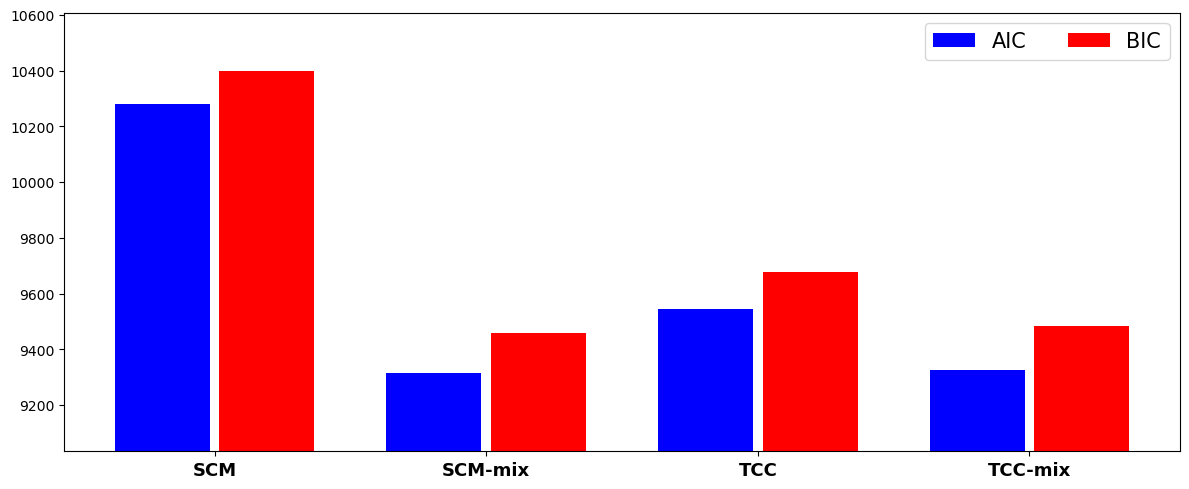

In [13]:
models_fit = {
    'SCM':     SCM_fit,
    'SCM-mix': SCM_mix_fit,
    'TCC':     TCC_fit,
    'TCC-mix': TCC_mix_fit,
}

comparison_df = print_model_comparison(models_fit, total_counts)
plot_aic_bic(comparison_df)

## Predictions

In [14]:
SCM_predictions     = SCM(SCM_fit.x, prepared_data)
SCM_mix_predictions = SCM_mix(SCM_mix_fit.x, prepared_data)
TCC_predictions     = TCC(TCC_fit.x, prepared_data, n_points=N_POINTS, x_range=X_RANGE)
TCC_mix_predictions = TCC_mix(TCC_mix_fit.x, prepared_data, n_points=N_POINTS, x_range=X_RANGE)

predictions_dict = {
    'SCM':     SCM_predictions,
    'SCM-mix': SCM_mix_predictions,
    'TCC':     TCC_predictions,
    'TCC-mix': TCC_mix_predictions,
}

## Correlations

In [15]:
for name, (pred_probs, _) in predictions_dict.items():
    print(f"{'='*30} Correlations for {name} {'='*30}")
    compute_correlations(pred_probs, data_matrix, SET_SIZES, POSITIONS, SUBJECTS, N_SS, N_POS)
    print("\n")

============================== Correlations for SCM ==============================
Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.935    p=0.000
SS=2, Pos=7        r=0.964    p=0.000
SS=2, Pos=11       r=0.960    p=0.000
SS=2, Pos=15       r=0.947    p=0.000
SS=5, Pos=3        r=0.860    p=0.000
SS=5, Pos=7        r=0.883    p=0.000
SS=5, Pos=11       r=0.805    p=0.000
SS=5, Pos=15       r=0.816    p=0.000
SS=8, Pos=3        r=0.897    p=0.000
SS=8, Pos=7        r=0.900    p=0.000
SS=8, Pos=11       r=0.880    p=0.000
SS=8, Pos=15       r=0.871    p=0.000


============================== Correlations for SCM-mix ==============================
Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.968    p=0.000
SS=2, Pos=7        r=0.978    p=0.000
SS=2, Pos=11       r=0.986    p=0.000
SS=2, Pos=15       r=0.975    p=0.000
SS=5, Pos=3        r=0.942    p=

## Visualization

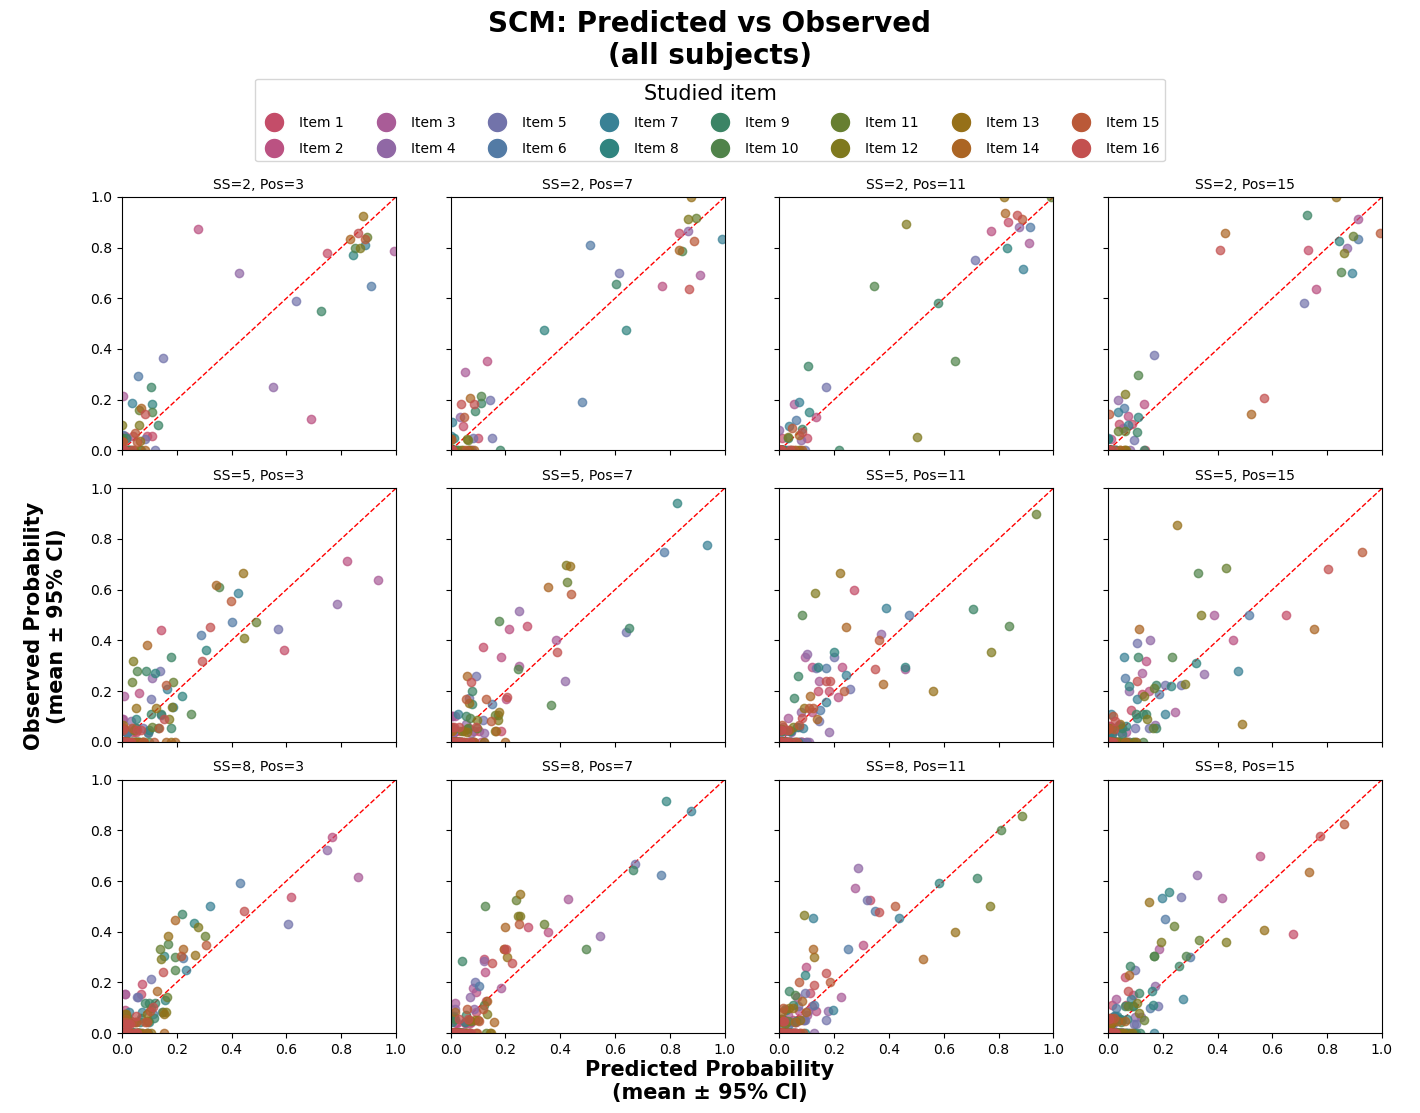

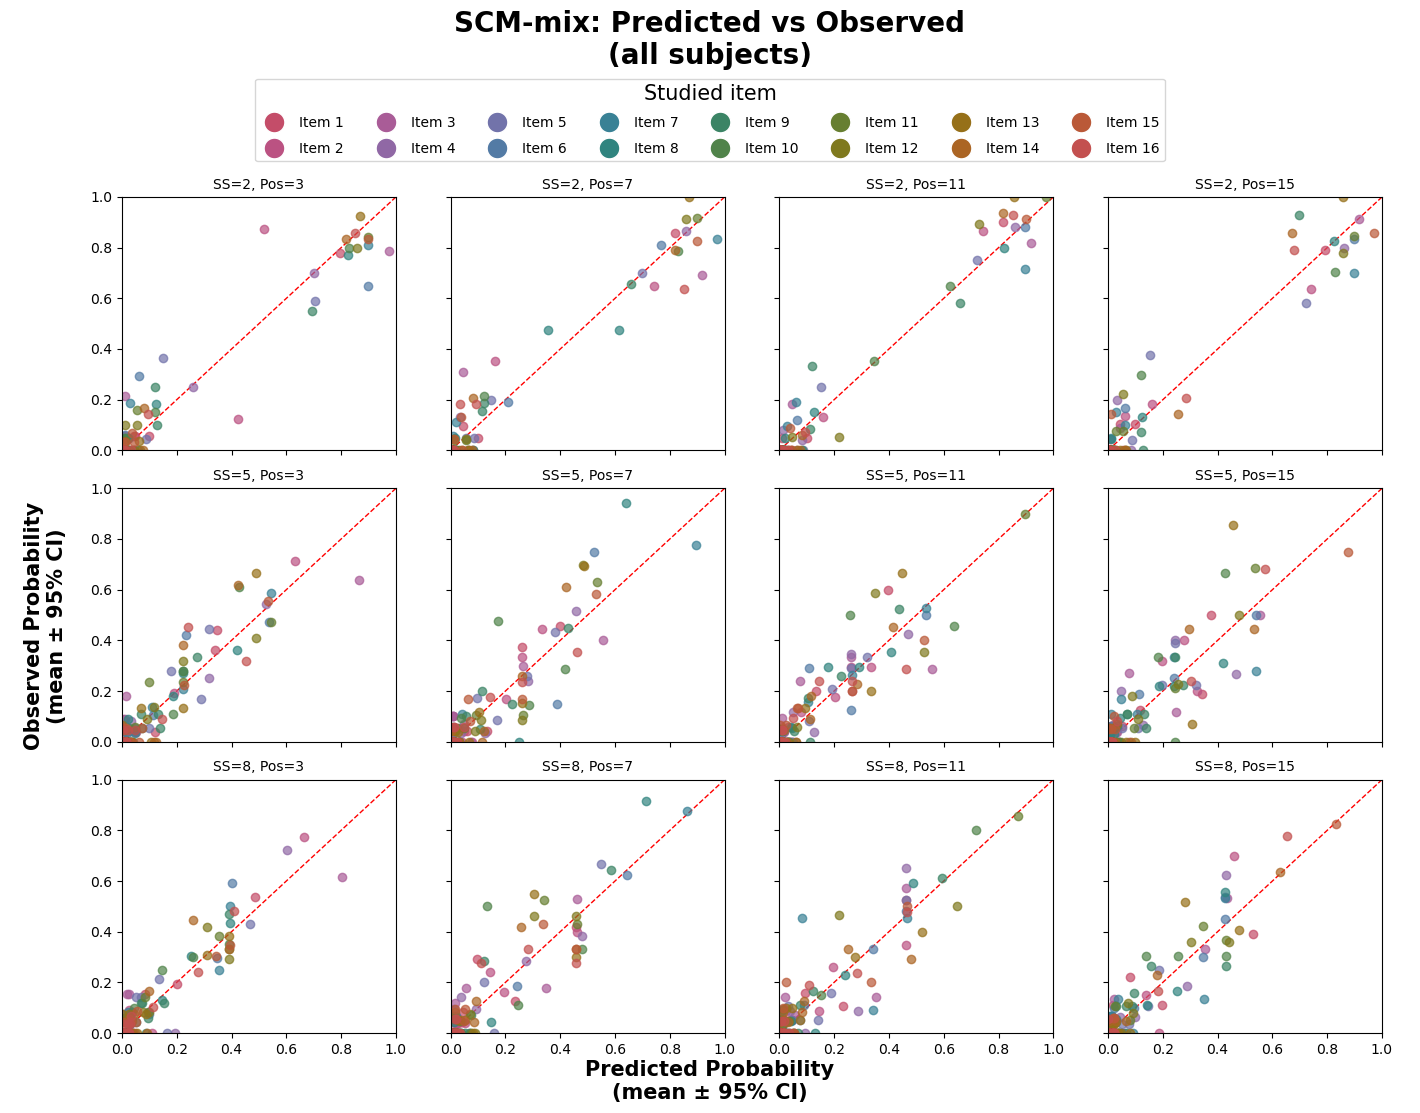

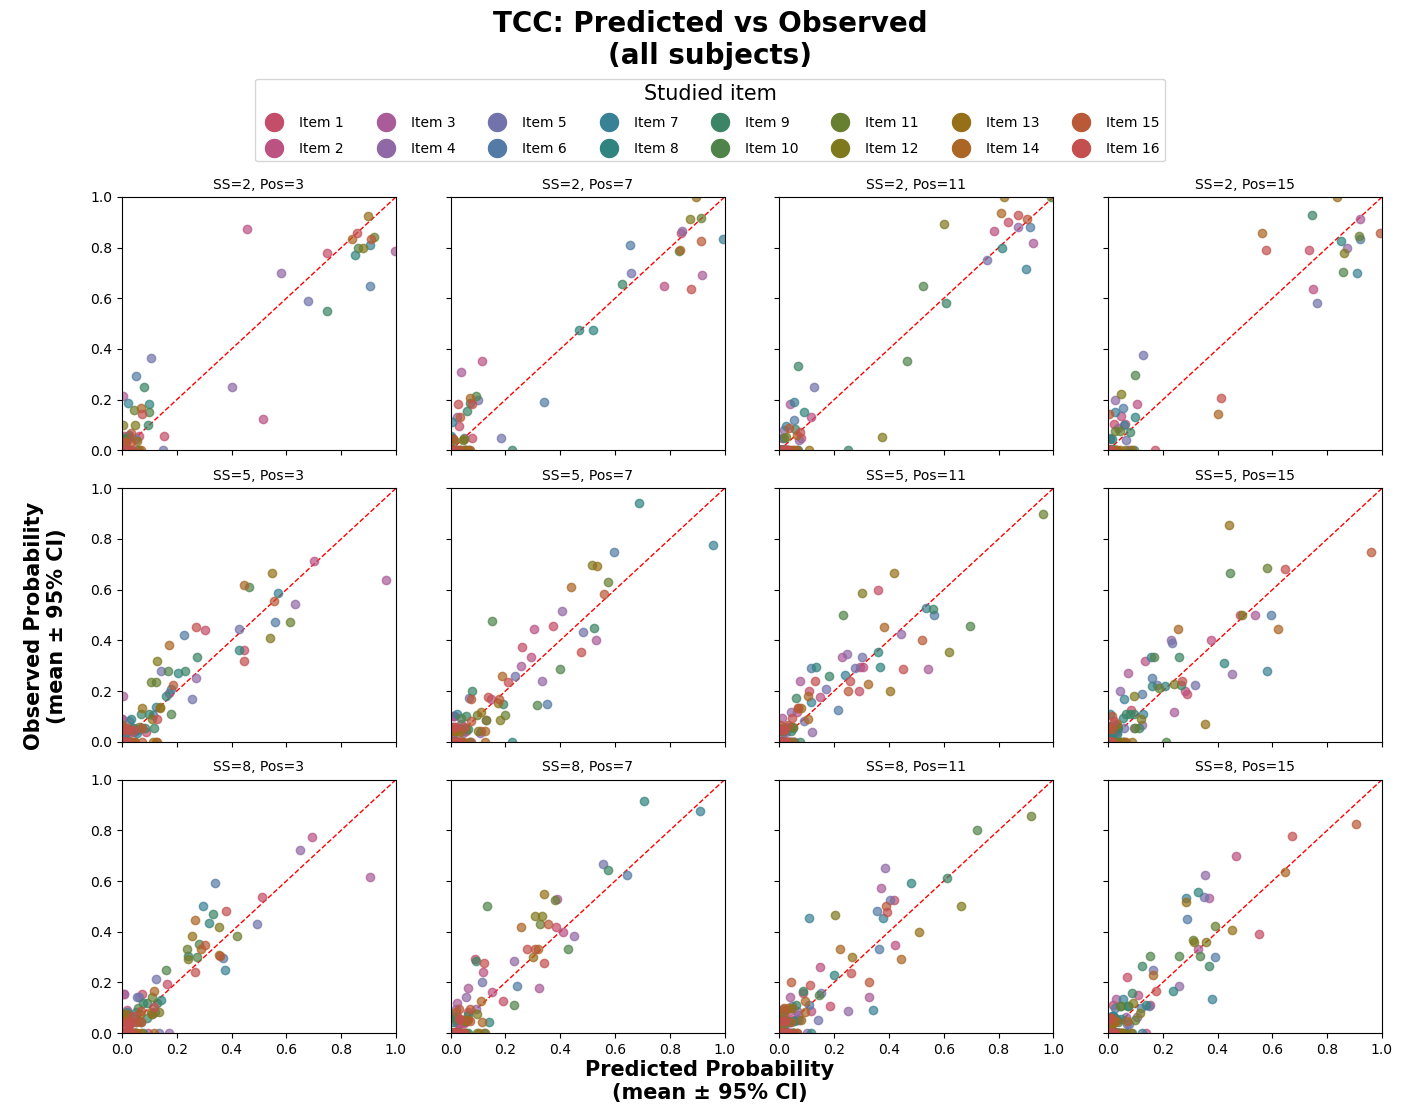

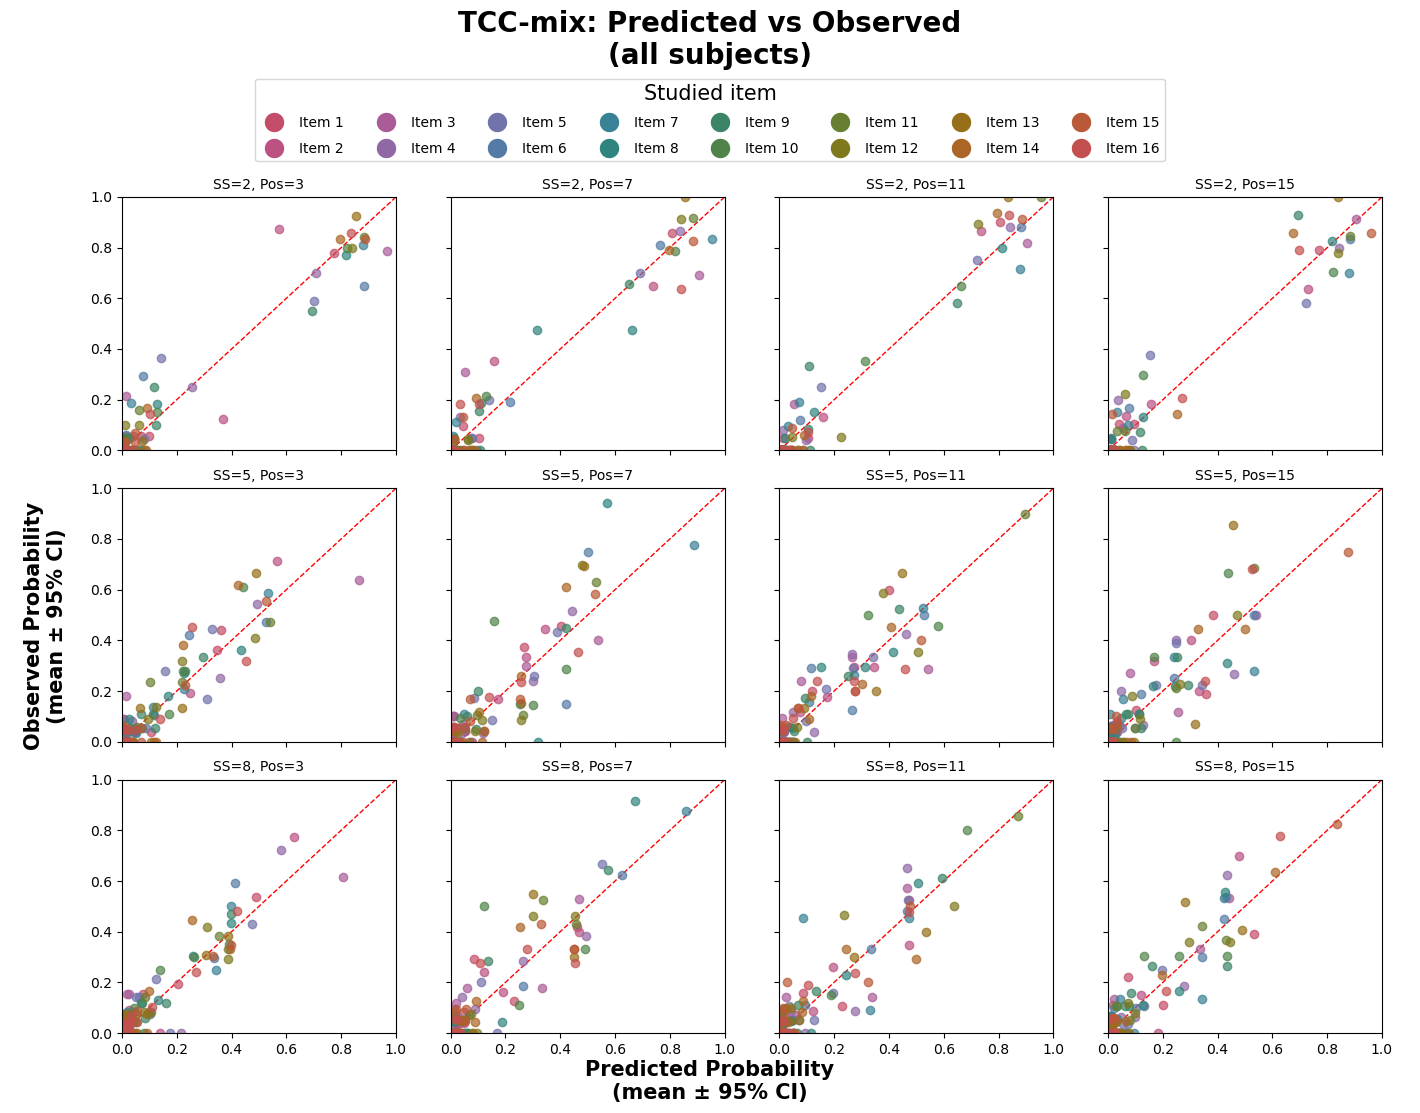

In [16]:
# Per-condition predicted vs observed (one plot per model)
for name, (pred_probs, _) in predictions_dict.items():
    plot_predicted_vs_observed(
        pred_probs, data_matrix, SET_SIZES, POSITIONS, SUBJECTS,
        N_SS, N_POS, model_name=name, error_type='ci'
    )

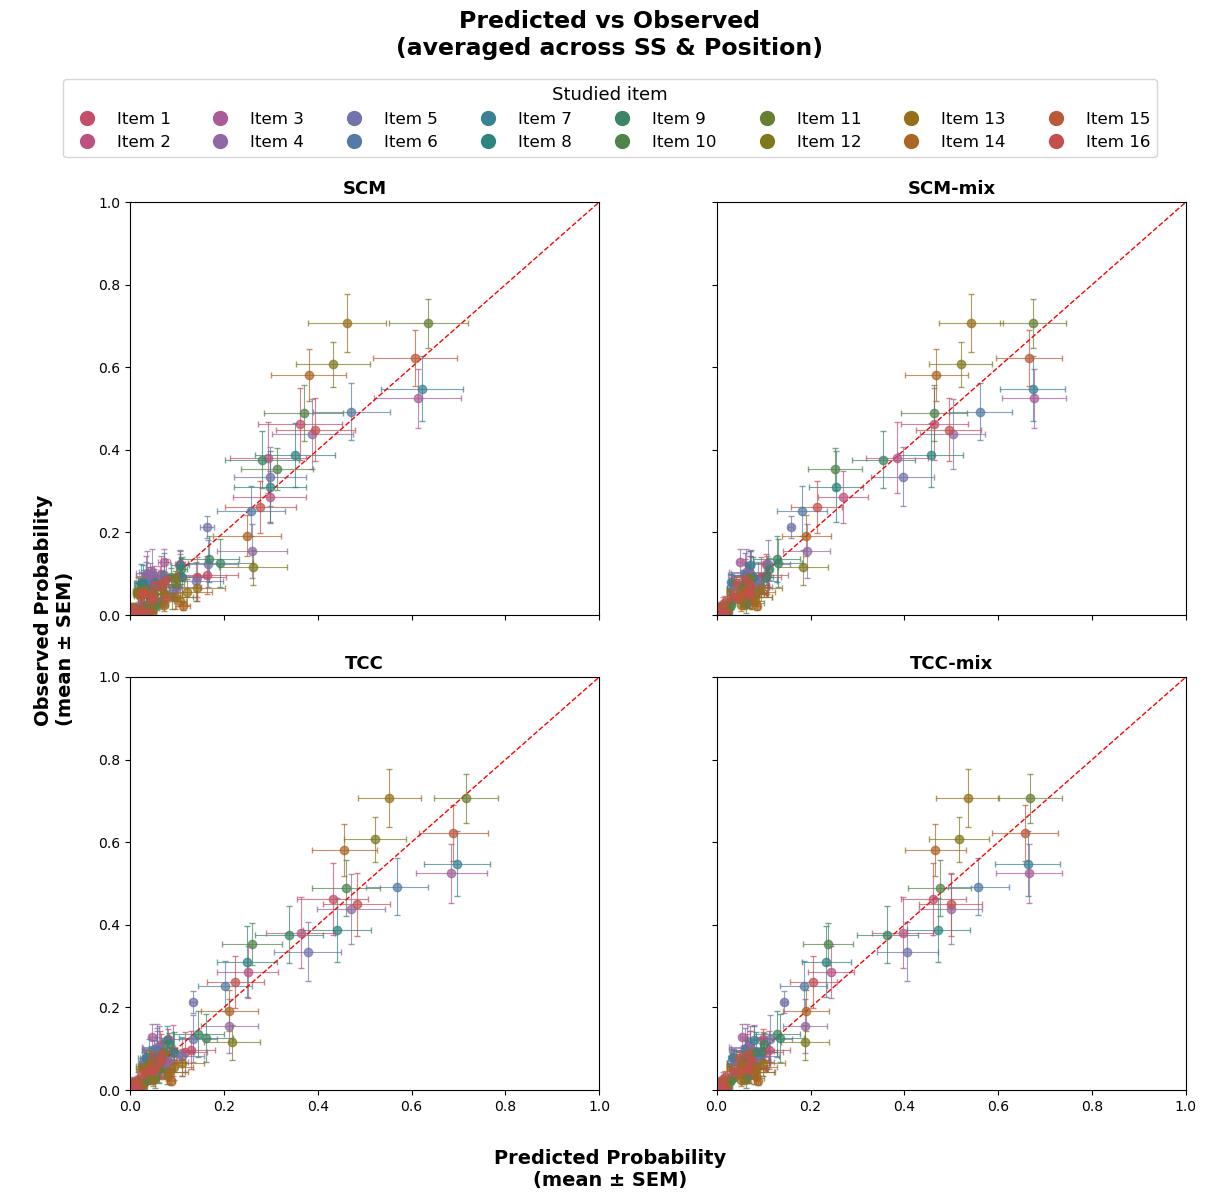

In [17]:
# Side-by-side model comparison
plot_predicted_vs_observed_comparison(
    predictions_dict, data_matrix,
    SUBJECTS, N_SS, N_POS,
    layout=[['SCM', 'SCM-mix'], ['TCC', 'TCC-mix']],
    error_type='sem'
)

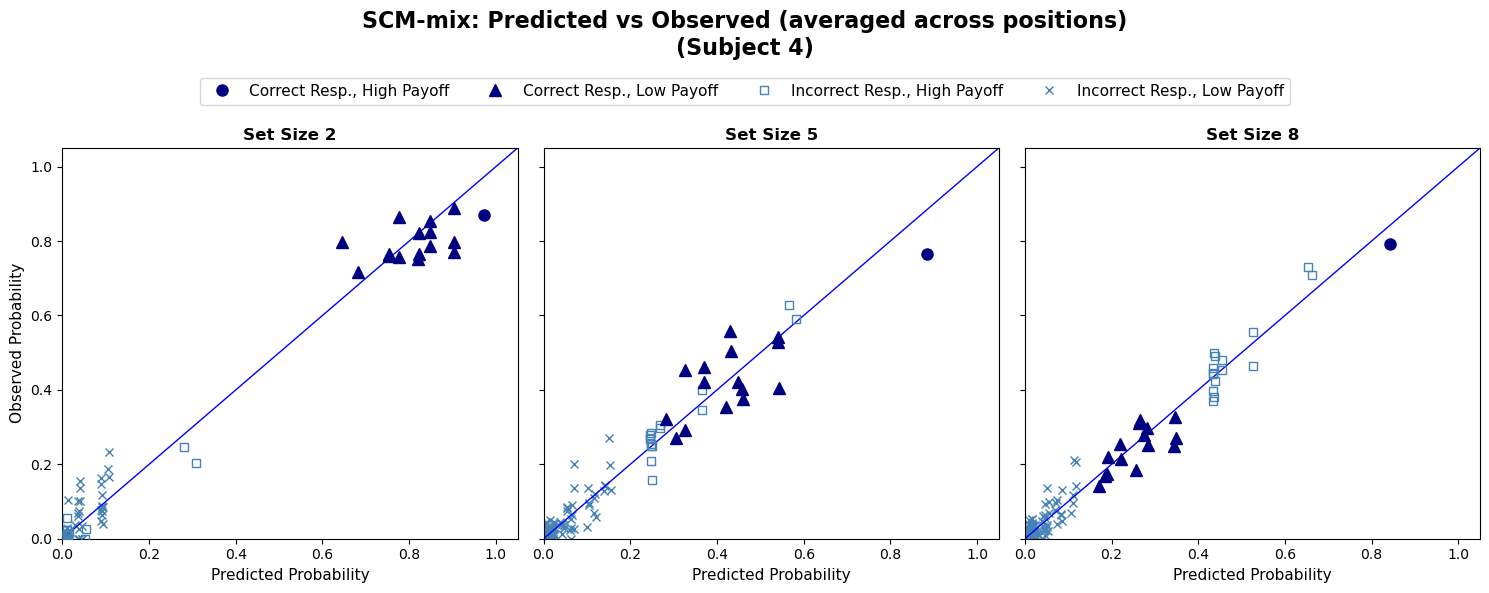

In [18]:
# Reproduce Fig 8 — averaged across positions, single subject
plot_pred_vs_obs_subject_avgpos(
    SCM_mix_predictions[0], data_matrix,
    SET_SIZES, POSITIONS, SUBJECTS, N_SS, N_POS,
    subject_id=4, model_name='SCM-mix'
)